In [ ]:
import pandas as pd
import os 
import duckdb

# Starting from scratch (preparation of P279 lifecycle file):

The following code read in the wdt_P279 from the wdt: lifecycle shards (truthy artifact). This only needs to be done once, but you can also use the resulting `P279_full.csv` and proceed to the next section.

In [ ]:
%%time
filepath = "wdt_P279/"
df=pd.DataFrame()
for f in os.listdir(path=filepath):
    df=pd.concat([df,pd.read_csv(filepath+f)])

In [ ]:
%%time
len(df)

Small "trick", we fill missing delete times with the current time: 

In [ ]:
df.columns=['S', 'P', 'O', 'T_c', 'U_c', 'T_d', 'U_d']
df["I_c"] = pd.to_datetime(df.T_c)
df["I_d"] = pd.to_datetime(df.T_d)
# Small "trick", we fill missing delete times with the current time:
df.I_d = df.I_d.fillna(value=pd.to_datetime("2026-05-12 00:00:00+00:00"))

df.to_csv("P279_full.csv")

# Quick start:

If you have P279_full.csv  already available, continue here. We read in relevant data into separate dataframes:

In [2]:
%%time
import pandas as pd
import os 
import duckdb
df_P279=pd.read_csv('P279_full.csv')
df_P279.drop(columns=['I'])
# in order to be able to proces the timestamps as intervals properly,...
#    1) we convert the T_c and T_d columns to correctly typed columns I_c and I_d:
df_P279["I_c"] = pd.to_datetime(df_P279.T_c)
df_P279["I_d"] = pd.to_datetime(df_P279.T_d)
#    2) as a small "trick", we fill missing delete times with the current time:
df_P279.I_d = df_P279.I_d.fillna(value=pd.to_datetime("2026-05-12 00:00:00+00:00"))

CPU times: user 23 s, sys: 1.96 s, total: 25 s
Wall time: 24.5 s


In [3]:
df_P279

,Unnamed: 0,S,P,O,T_c,U_c,T_d,U_d,I_c,I_d,I
0,0,wd:Q139372,wdt:P279,wd:Q811909,2017-09-03T08:10:53Z,Thomas11,NaN,NaN,2017-09-03 08:10:53+00:00,2026-05-12 00:00:00+00:00,"[2017-09-03 08:10:53+00:00, 2026-05-12 00:00:0..."
1,1,wd:Q139424,wdt:P279,wd:Q473972,2015-06-16T20:20:43Z,Michiel1972,2015-06-30T19:00:32Z,Eldizzino,2015-06-16 20:20:43+00:00,2015-06-30 19:00:32+00:00,"[2015-06-16 20:20:43+00:00, 2015-06-30 19:00:3..."
2,2,wd:Q139424,wdt:P279,wd:Q2975935,2015-06-30T19:00:32Z,Eldizzino,NaN,NaN,2015-06-30 19:00:32+00:00,2026-05-12 00:00:00+00:00,"[2015-06-30 19:00:32+00:00, 2026-05-12 00:00:0..."
3,3,wd:Q139425,wdt:P279,wd:Q193622,2014-10-20T08:37:47Z,Pasleim,2015-02-10T08:36:20Z,Gymel,2014-10-20 08:37:47+00:00,2015-02-10 08:36:20+00:00,"[2014-10-20 08:37:47+00:00, 2015-02-10 08:36:2..."
4,4,wd:Q139425,wdt:P279,wd:Q193622,2016-10-15T11:44:25Z,Pasleim,2023-05-12T07:11:41Z,RVA2869,2016-10-15 11:44:25+00:00,2023-05-12 07:11:41+00:00,"[2016-10-15 11:44:25+00:00, 2023-05-12 07:11:4..."
...,...,...,...,...,...,...,...,...,...,...,...
6704799,3096,wd:Q5164608,wdt:P279,wd:Q15978655,2021-06-03T08:05:23Z,Cruzate1492,NaN,NaN,2021-06-03 08:05:23+00:00,2026-05-12 00:00:00+00:00,"[2021-06-03 08:05:23+00:00, 2026-05-12 00:00:0..."
6704800,3097,wd:Q5164621,wdt:P279,wd:Q104493,2020-11-13T23:24:28Z,Zhenqinli,NaN,NaN,2020-11-13 23:24:28+00:00,2026-05-12 00:00:00+00:00,"[2020-11-13 23:24:28+00:00, 2026-05-12 00:00:0..."
6704801,3098,wd:Q5164623,wdt:P279,wd:Q334911,2019-02-13T21:31:26Z,Zhenqinli,NaN,NaN,2019-02-13 21:31:26+00:00,2026-05-12 00:00:00+00:00,"[2019-02-13 21:31:26+00:00, 2026-05-12 00:00:0..."
6704802,3099,wd:Q5164625,wdt:P279,wd:Q30336093,2017-12-18T11:57:27Z,Fractaler,2023-10-25T21:03:12Z,Zhenqinli,2017-12-18 11:57:27+00:00,2023-10-25 21:03:12+00:00,"[2017-12-18 11:57:27+00:00, 2023-10-25 21:03:1..."


# Experiment for constaint validity checking over time:
For this particular experiment, we're interested in checking the validity of the subject type constriaint(s) of property P36 (capital) on subject entity Q30 (USA), over time,
inspired by Figure 1 in our paper:

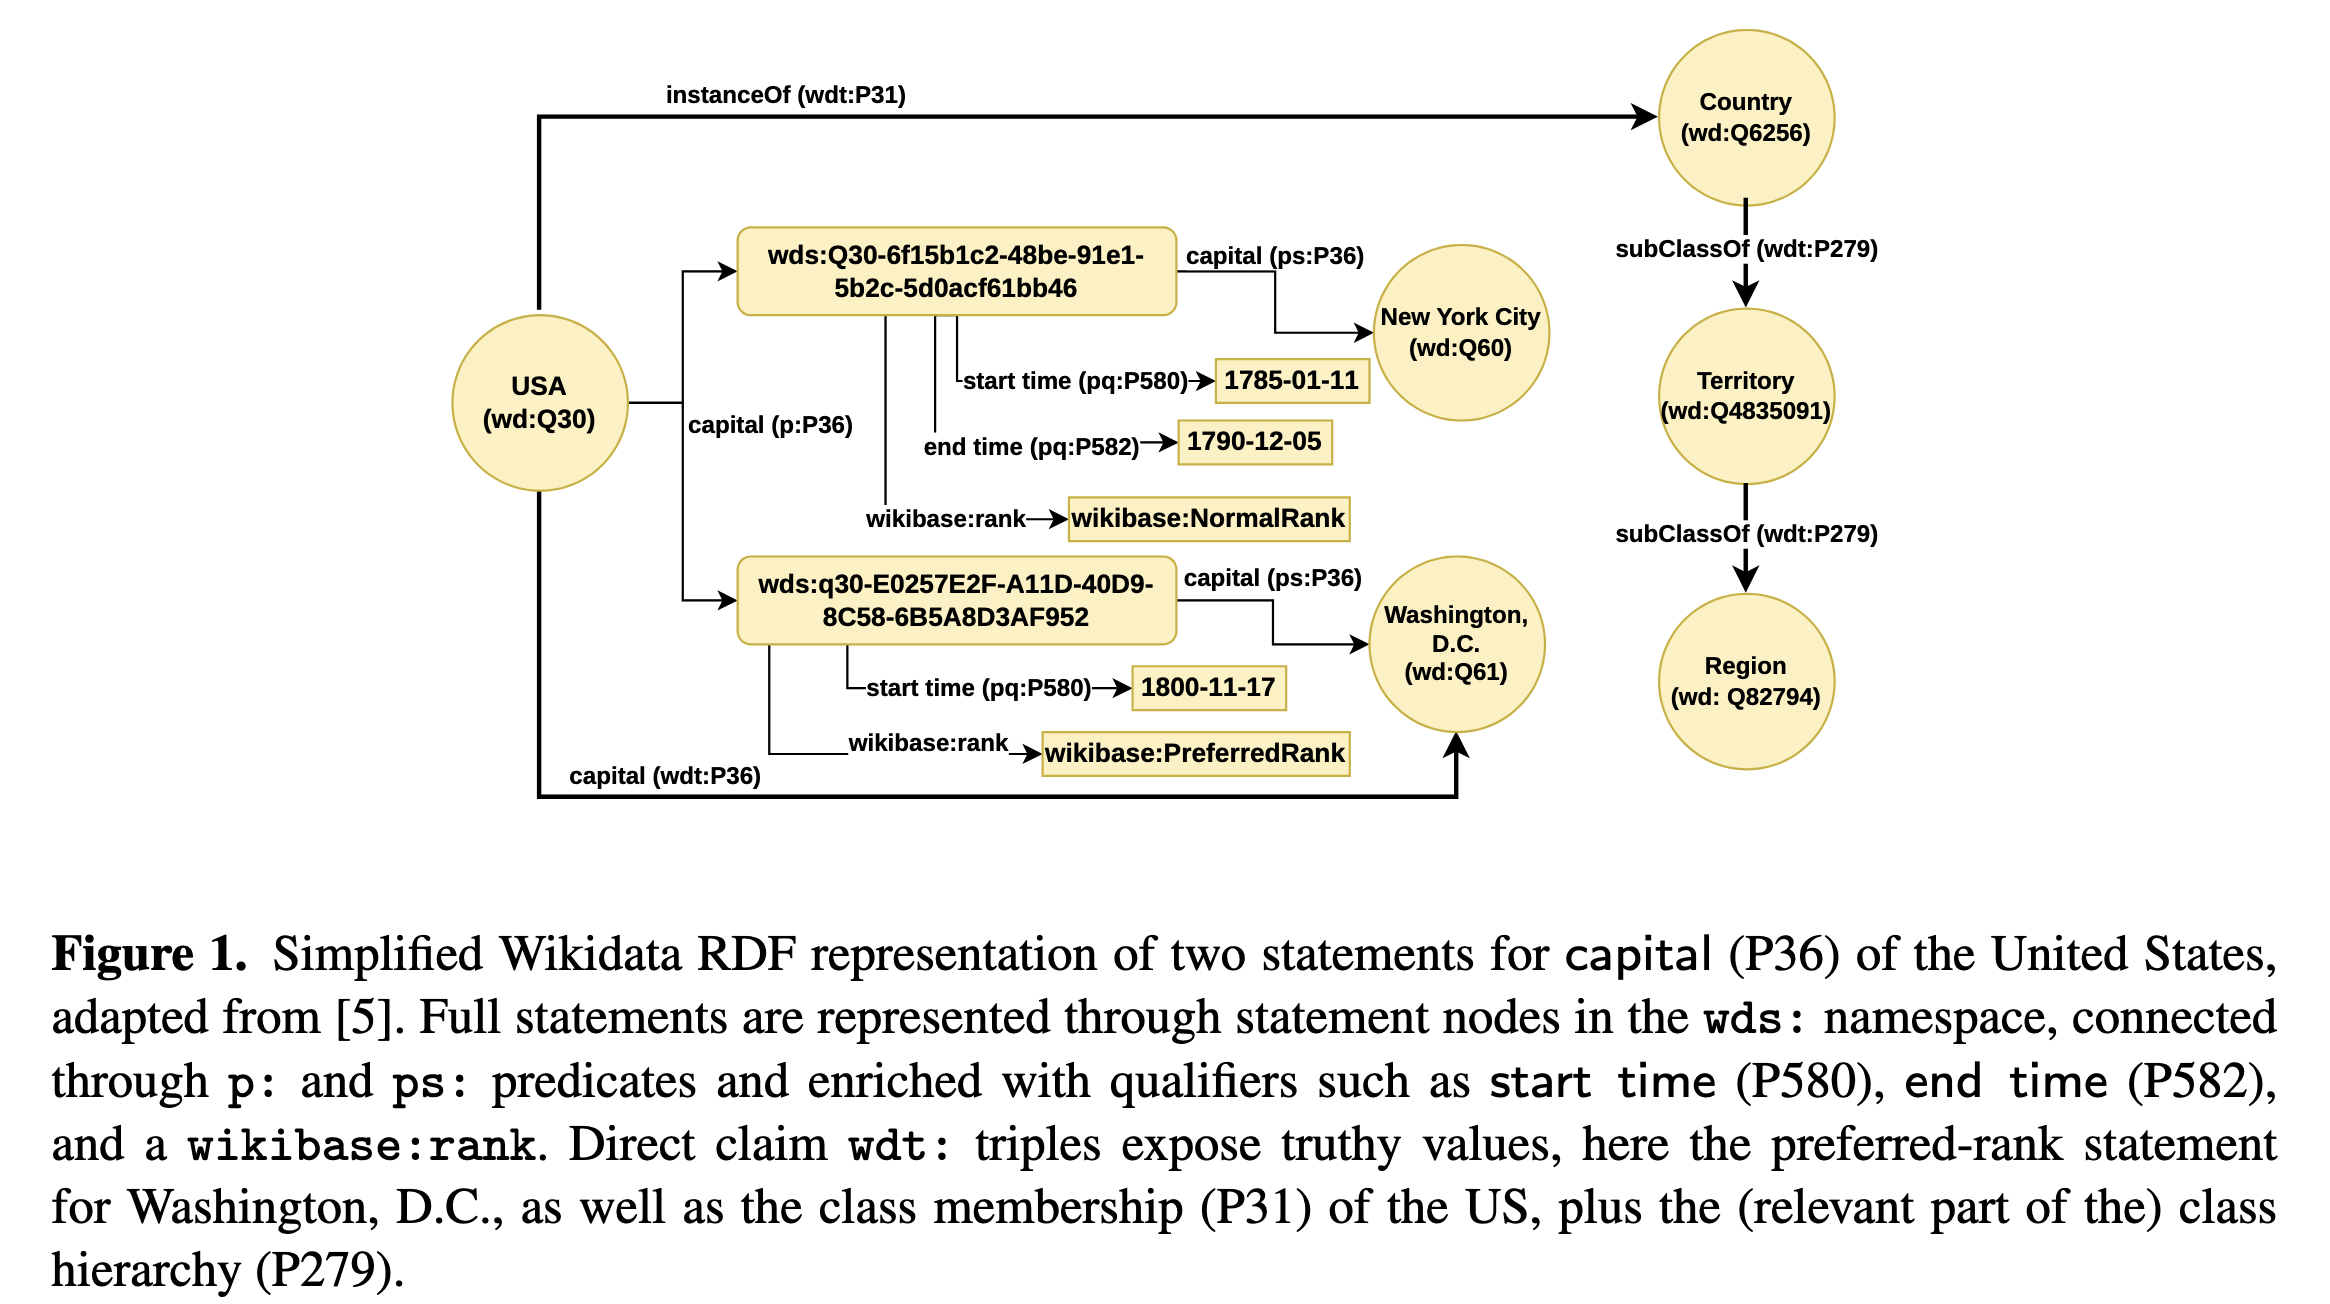

For the experiment we need:
* the lifecycle of (Q30, P36, ...) statements from the truthy statements: for convenience, we have stored these in the file: `Q30_P36.csv`
* the lifecycle of (Q30, P31, ...) statements from the truthy statements, i.e. the subject classes for Q30: for convenience, we have stored these in the file: `Q30_P31.csv`
* the constraint lifecycle (from $CoL$) of the subject type constraint(s) of P36: for convenience we have stores this in the file `P36_constraint.csv`

* finally, if we want to check validity wrt. to also taking into account the class hierarchy (considering subclasses of the pq:P2308 mentioned classes), we need the *subclass hierarchy artifct*, i.e., the above created df_P279 dataframe.

We first loaf and pre-process the other files, as we did for df_P279: 


In [4]:
# This file contains all details about the P36_ subject type constriant that Nicolas sent me: 
df_P36=pd.read_csv('P36_constraint.csv')

df_P36["I_c"] = pd.to_datetime(df_P36.T_c)
df_P36["I_d"] = pd.to_datetime(df_P36.T_d)
# again, same small "trick", we fill missing delete times with the current time:
df_P36.I_d = df_P36.I_d.fillna(value=pd.to_datetime("2026-05-12 00:00:00+00:00"))

# This file contains all details about the the capital (P36) of the USA (Q30), we will use this as a demonstration for how value type constraint can be checked: 

df_Q30_P36=pd.read_csv('Q30_P36.csv')


df_Q30_P36["I_c"] = pd.to_datetime(df_Q30_P36.T_c)
df_Q30_P36["I_d"] = pd.to_datetime(df_Q30_P36.T_d)
# again, same small "trick", we fill missing delete times with the current time:
df_Q30_P36.I_d = df_Q30_P36.I_d.fillna(value=pd.to_datetime("2026-05-12 00:00:00+00:00"))

# This file contains all details about the types (P31) of the USA (Q30), we will use this as a demonstration for how value type constraint can be checked: 

df_Q30_P31=pd.read_csv('Q30_P31.csv')

df_Q30_P31["I_c"] = pd.to_datetime(df_Q30_P31.T_c)
df_Q30_P31["I_d"] = pd.to_datetime(df_Q30_P31.T_d)
# again, same small "trick", we fill missing delete times with the current time:
df_Q30_P31.I_d = df_Q30_P31.I_d.fillna(value=pd.to_datetime("2026-05-12 00:00:00+00:00"))

Only the objects of pq:P2308 are relevant, as they contain the relevant classes in the object position, so we can filter these out, and think about how we can temporally join them with HL (P279):

In [6]:
df_P36_P2308=df_P36[df_P36.P=='pq:P2308']
display(df_P36_P2308)
display(df_P279)

,S,P,O,T_c,U_c,T_d,U_d,I_c,I_d
0,wds:P36-2e0bece7-4b18-609a-f9dc-cd3f480e3cfc,pq:P2308,wd:Q6256,2017-07-05T15:49:09Z,Dhx1,2017-07-13T04:56:52Z,KrBot,2017-07-05 15:49:09+00:00,2017-07-13 04:56:52+00:00
5,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q1964689,2019-01-08T15:44:21Z,Trade,2019-07-27T18:18:19Z,Trade,2019-01-08 15:44:21+00:00,2019-07-27 18:18:19+00:00
9,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q56061,2017-07-13T04:57:06Z,KrBot,NaN,NaN,2017-07-13 04:57:06+00:00,2026-05-12 00:00:00+00:00
10,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q486972,2017-07-13T04:57:07Z,KrBot,NaN,NaN,2017-07-13 04:57:07+00:00,2026-05-12 00:00:00+00:00
11,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q23442,2018-07-02T09:59:54Z,Nvrandow,NaN,NaN,2018-07-02 09:59:54+00:00,2026-05-12 00:00:00+00:00
12,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q1145276,2019-07-27T18:18:19Z,Trade,NaN,NaN,2019-07-27 18:18:19+00:00,2026-05-12 00:00:00+00:00
13,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q3327870,2020-04-13T13:31:51Z,Bouzinac,NaN,NaN,2020-04-13 13:31:51+00:00,2026-05-12 00:00:00+00:00
14,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2020-08-23T14:21:15Z,Romaine,NaN,NaN,2020-08-23 14:21:15+00:00,2026-05-12 00:00:00+00:00
15,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q1414991,2020-08-23T14:21:15Z,Romaine,NaN,NaN,2020-08-23 14:21:15+00:00,2026-05-12 00:00:00+00:00
16,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q2775969,2021-04-05T18:54:21Z,Mith,NaN,NaN,2021-04-05 18:54:21+00:00,2026-05-12 00:00:00+00:00


,Unnamed: 0,S,P,O,T_c,U_c,T_d,U_d,I_c,I_d,I
0,0,wd:Q139372,wdt:P279,wd:Q811909,2017-09-03T08:10:53Z,Thomas11,NaN,NaN,2017-09-03 08:10:53+00:00,2026-05-12 00:00:00+00:00,"[2017-09-03 08:10:53+00:00, 2026-05-12 00:00:0..."
1,1,wd:Q139424,wdt:P279,wd:Q473972,2015-06-16T20:20:43Z,Michiel1972,2015-06-30T19:00:32Z,Eldizzino,2015-06-16 20:20:43+00:00,2015-06-30 19:00:32+00:00,"[2015-06-16 20:20:43+00:00, 2015-06-30 19:00:3..."
2,2,wd:Q139424,wdt:P279,wd:Q2975935,2015-06-30T19:00:32Z,Eldizzino,NaN,NaN,2015-06-30 19:00:32+00:00,2026-05-12 00:00:00+00:00,"[2015-06-30 19:00:32+00:00, 2026-05-12 00:00:0..."
3,3,wd:Q139425,wdt:P279,wd:Q193622,2014-10-20T08:37:47Z,Pasleim,2015-02-10T08:36:20Z,Gymel,2014-10-20 08:37:47+00:00,2015-02-10 08:36:20+00:00,"[2014-10-20 08:37:47+00:00, 2015-02-10 08:36:2..."
4,4,wd:Q139425,wdt:P279,wd:Q193622,2016-10-15T11:44:25Z,Pasleim,2023-05-12T07:11:41Z,RVA2869,2016-10-15 11:44:25+00:00,2023-05-12 07:11:41+00:00,"[2016-10-15 11:44:25+00:00, 2023-05-12 07:11:4..."
...,...,...,...,...,...,...,...,...,...,...,...
6704799,3096,wd:Q5164608,wdt:P279,wd:Q15978655,2021-06-03T08:05:23Z,Cruzate1492,NaN,NaN,2021-06-03 08:05:23+00:00,2026-05-12 00:00:00+00:00,"[2021-06-03 08:05:23+00:00, 2026-05-12 00:00:0..."
6704800,3097,wd:Q5164621,wdt:P279,wd:Q104493,2020-11-13T23:24:28Z,Zhenqinli,NaN,NaN,2020-11-13 23:24:28+00:00,2026-05-12 00:00:00+00:00,"[2020-11-13 23:24:28+00:00, 2026-05-12 00:00:0..."
6704801,3098,wd:Q5164623,wdt:P279,wd:Q334911,2019-02-13T21:31:26Z,Zhenqinli,NaN,NaN,2019-02-13 21:31:26+00:00,2026-05-12 00:00:00+00:00,"[2019-02-13 21:31:26+00:00, 2026-05-12 00:00:0..."
6704802,3099,wd:Q5164625,wdt:P279,wd:Q30336093,2017-12-18T11:57:27Z,Fractaler,2023-10-25T21:03:12Z,Zhenqinli,2017-12-18 11:57:27+00:00,2023-10-25 21:03:12+00:00,"[2017-12-18 11:57:27+00:00, 2023-10-25 21:03:1..."


## Considering (transitive) subclasses for checking subject-type constraints:

In order to check class implicit memberships relevant to checking the P36 partially overlapping intervals where the P279* joins only in an intersection with an subinterval with the P2308 object are witnesses to safe a subclass membership. As a next step, we compute the relevant materialisation of $HL^*$, i.e., materializing relevant subclasses transitively (in interval intersections) up to a fixpoint.

We use duckDB as a "deductive database" here, implementing the fixpoint computation of relevant subclasses in an iterative loop:  

In [9]:
sublasses_until_fixpoint = df_P36_P2308.drop(columns=['T_c','T_d','U_c','U_d'])
# The class itself is a relevant subclass (for the whole duration of the constraint validity):
sublasses_until_fixpoint['subclass'] = sublasses_until_fixpoint['O']
fixpoint=False
iteration_result = []

display(sublasses_until_fixpoint[sublasses_until_fixpoint["O"] == "wd:Q82794"].sort_values(by=["I_d"]).tail(20))
display(sublasses_until_fixpoint[sublasses_until_fixpoint["I_c"] == sublasses_until_fixpoint["I_d"]].sort_values(by=["I_d"]).tail(20))


,S,P,O,I_c,I_d,subclass
14,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2020-08-23 14:21:15+00:00,2026-05-12 00:00:00+00:00,wd:Q82794


,S,P,O,I_c,I_d,subclass


In [10]:
%%time
while (not fixpoint):
    query_iteration = """
        (SELECT 
            sublasses_until_fixpoint.S,	
            sublasses_until_fixpoint.P,
            sublasses_until_fixpoint.O,
            -- the overlapping/intersecting interval:
            -- maximume of the creation dates 
            if(sublasses_until_fixpoint.I_c > df_P279.I_c,sublasses_until_fixpoint.I_c,df_P279.I_c) as I_c,
            -- minimum of the deletion dates 
            if(sublasses_until_fixpoint.I_d < df_P279.I_d,sublasses_until_fixpoint.I_d,df_P279.I_d) as I_d,
            df_P279.S as subclass,
        FROM sublasses_until_fixpoint
        JOIN df_P279
        -- In this version, we take the intersection the intersecting/overlapping, non-empty intervals
        ON sublasses_until_fixpoint.I_c <= df_P279.I_d 
        AND sublasses_until_fixpoint.I_d >= df_P279.I_c
        AND sublasses_until_fixpoint.I_c != df_P279.I_d 
        AND sublasses_until_fixpoint.I_d != df_P279.I_c 
        AND df_P279.O = sublasses_until_fixpoint.subclass
        )
        UNION
        (SELECT * FROM sublasses_until_fixpoint WHERE sublasses_until_fixpoint.I_c != sublasses_until_fixpoint.I_d)        
        """
        
    iteration_result= duckdb.query(query_iteration).to_df()
    print(len(iteration_result))
    
    if (len(iteration_result) == len(sublasses_until_fixpoint)):
        fixpoint=True
        print("Fixpoint reached!")
    else:
        sublasses_until_fixpoint=iteration_result


2158
27471
68668
123271
183791
237994
271766
288502
298090
302349
303480
303900
304000
304030
304044
304044
Fixpoint reached!
CPU times: user 8.84 s, sys: 879 ms, total: 9.72 s
Wall time: 3.48 s


In [12]:
print(len(sublasses_until_fixpoint))

304044


As we can see, the cpmutation, while finishing relatively quickly, even for a single constraint intance, is realtively expensive: it results in +300K distinct relevant subslass validity intervals, for a single constraint type instance lifecycle (i.e., subject type-constraint instances of property P36).

***Note***: cyclic subclassOf definitions with intersecting validitiy intervals could create temporally nested duplicates in this approach: I assume there is optimization potential when you eliminate/merge such overlapping duplicates. I *think* if the subclass hierarchy is acyclic, then this is not a big deal (but have no proof of this yet).                                                          

### Intermediate result:

We will use these computed fixcpoint intervals in the next step for testing:

In [122]:
df_P36_P2308_HL_star = until_fixpoint_finegrained

Again, we write the result for intermediate storage to a separate file (optional step):       

In [113]:
%%time
df_P36_P2308_HL_star.to_csv("P36_P2308_HL_star_intersecting_intervals_subclasses_materialized.csv")

CPU times: user 3.95 s, sys: 35.8 ms, total: 3.99 s
Wall time: 3.99 s


# Testing a constraint over time: (this is WORK IN PROGRESS!)


If we now wanted to test the constraint on a certain subject entity, such as Q30, we can use the constraint lifecycle of the Q30 entity, which is stored in the Q30_P36.csv file. Additionallt, we need the class memberships for Q30, that are present in Q30_P31.csv.
We can now use the temporal transitive class memberships of all relevant classes, that we computed above in `df_P36_P2308_HL_star` to compute all validity intervals, by simply joining all three on the temporal overlaps:

In [138]:
display(df_Q30_P36.head())
display(df_Q30_P31.head())
# For our example, check relevant intervals where country was a subclass of region:
display(df_P36_P2308_HL_star[(df_P36_P2308_HL_star["O"] == "wd:Q82794") & (df_P36_P2308_HL_star["subclass"] == "wd:Q6256")])

,S,P,O,T_c,U_c,T_d,U_d,I_c,I_d
0,wd:Q30,wdt:P36,wd:Q61,2013-02-04T21:41:39Z,JoonaZZ,2013-02-16T11:21:45Z,Aude,2013-02-04 21:41:39+00:00,2013-02-16 11:21:45+00:00
1,wd:Q30,wdt:P36,wd:Q482386,2013-02-16T11:21:45Z,Aude,2013-02-16T11:23:07Z,Aude,2013-02-16 11:21:45+00:00,2013-02-16 11:23:07+00:00
2,wd:Q30,wdt:P36,wd:Q1967325,2013-02-16T11:23:07Z,Aude,2013-02-16T11:24:10Z,Aude,2013-02-16 11:23:07+00:00,2013-02-16 11:24:10+00:00
3,wd:Q30,wdt:P36,wd:Q2431532,2013-02-16T11:24:10Z,Aude,2013-02-16T11:25:10Z,Aude,2013-02-16 11:24:10+00:00,2013-02-16 11:25:10+00:00
4,wd:Q30,wdt:P36,wd:Q79281,2013-02-16T11:25:10Z,Aude,2013-02-16T11:26:09Z,Aude,2013-02-16 11:25:10+00:00,2013-02-16 11:26:09+00:00


,S,P,O,T_c,U_c,T_d,U_d,I_c,I_d
0,wd:Q30,wdt:P31,wd:Q6256,2013-02-04T22:08:34Z,Napoleon.tan,2013-02-05T02:25:00Z,Ypnypn,2013-02-04 22:08:34+00:00,2013-02-05 02:25:00+00:00
1,wd:Q30,wdt:P31,wd:Q6256,2013-02-05T16:13:05Z,Napoleon.tan,2013-02-06T14:29:27Z,Ypnypn,2013-02-05 16:13:05+00:00,2013-02-06 14:29:27+00:00
2,wd:Q30,wdt:P31,wd:Q7270,2013-02-07T05:48:27Z,MarrickLip,2013-02-07T18:02:45Z,Ypnypn,2013-02-07 05:48:27+00:00,2013-02-07 18:02:45+00:00
3,wd:Q30,wdt:P31,wd:Q3624078,2013-02-05T02:25:00Z,Ypnypn,2016-02-24T18:37:22Z,Tfmorris1,2013-02-05 02:25:00+00:00,2016-02-24 18:37:22+00:00
4,wd:Q30,wdt:P31,wd:Q6688521,2014-06-05T18:45:23Z,Thomas11,2016-02-24T18:37:22Z,Tfmorris1,2014-06-05 18:45:23+00:00,2016-02-24 18:37:22+00:00


,S,P,O,I_c,I_d,subclass
45731,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2022-12-29 19:24:14+01:00,2023-02-05 20:52:04+01:00,wd:Q6256
45737,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2022-01-04 22:35:52+01:00,2022-04-13 18:53:53+02:00,wd:Q6256
55314,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2022-07-23 06:24:45+02:00,2023-02-03 09:59:15+01:00,wd:Q6256
93086,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2025-01-25 06:13:34+01:00,2026-05-12 02:00:00+02:00,wd:Q6256
102565,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2022-04-13 18:51:36+02:00,2022-04-13 18:53:20+02:00,wd:Q6256
102568,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2020-08-23 16:21:15+02:00,2021-06-27 20:54:37+02:00,wd:Q6256
226349,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2022-04-13 19:02:17+02:00,2022-07-23 06:24:45+02:00,wd:Q6256
254889,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2023-09-02 21:47:44+02:00,2023-09-03 16:59:32+02:00,wd:Q6256
283396,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2024-12-05 21:48:25+01:00,2026-05-12 02:00:00+02:00,wd:Q6256
292937,wds:P36-3DCE3955-2EA4-4BA7-9410-F85848F3DB5B,pq:P2308,wd:Q82794,2023-07-18 09:18:45+02:00,2026-05-12 02:00:00+02:00,wd:Q6256


Computing the join:

For better illustration (this could be done in one query), we proceed in two steps:
* Step1: the first part point the intersecting intervals of `df_Q30_P36` and the subject classes from `df_Q30_P31`, determining pairs of "witness classes" C1,C1, that would warrant constraint validity
* Step2: in the second part/step we check wh ether there are overlapping (transitive) subclass-validity intervals for C2 subclassOf C1, by joining with `df_P36_P2308_HL_star`


### Step 1:

In [155]:
%%time
temporal_subject_type_validity_part1 = """
        SELECT 
            P36.S,	
            P36.P,
            P36.O,
            P31.O AS C,
            -- the overlapping/intersecting interval:
            -- maximume of the creation dates 
            if(P36.I_c > P31.I_c,P36.I_c,P31.I_c) as I_c,
            -- minimum of the deletion dates 
            if(P36.I_d < P31.I_d,P36.I_d,P31.I_d) as I_d,
        FROM df_Q30_P36 AS P36
        JOIN df_Q30_P31 AS P31
        -- In this version, we take the intersection the intersecting/overlapping, non-empty intervals
        ON P31.I_c <= P36.I_d 
        AND P31.I_d >= P36.I_c
        AND P31.I_c != P36.I_d 
        AND P31.I_d != P36.I_c 
        AND P36.S = P31.S
        """
        
df_part1 = duckdb.query(temporal_subject_type_validity_part1).to_df()
display(df_part1[(df_part1["C"] == "wd:Q6256")])
display(df_part1[(df_part1["C"] == "wd:Q82794")])  #this will be empty, obviously, the region class does not appear


,S,P,O,C,I_c,I_d
0,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,2016-03-27 17:33:08+02:00,2016-08-14 11:21:42+02:00
9,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,2016-08-14 13:20:18+02:00,2017-02-18 07:12:09+01:00
18,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,2017-02-23 14:08:22+01:00,2018-12-30 11:49:47+01:00
21,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,2019-02-05 06:07:55+01:00,2020-07-22 11:33:45+02:00
30,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,2020-08-27 17:20:30+02:00,2026-05-12 02:00:00+02:00
32,wd:Q30,wdt:P36,wd:Q1345,wd:Q6256,2016-03-27 15:40:37+02:00,2016-03-27 15:41:02+02:00
36,wd:Q30,wdt:P36,wd:Q60,wd:Q6256,2016-03-27 15:40:37+02:00,2016-03-27 15:40:49+02:00
45,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,2015-05-05 12:25:18+02:00,2016-03-27 15:40:37+02:00
52,wd:Q30,wdt:P36,wd:Q60,wd:Q6256,2015-05-05 12:30:05+02:00,2015-06-15 09:40:34+02:00
56,wd:Q30,wdt:P36,wd:Q60,wd:Q6256,2015-05-05 12:20:28+02:00,2015-05-05 12:23:16+02:00


,S,P,O,C,I_c,I_d


CPU times: user 22.5 ms, sys: 2.75 ms, total: 25.3 ms
Wall time: 22.9 ms


### Step2: 

The following returns all valid intervals, where the subject of P36 was a member of the direct Class ($C1$) which in the given interval of $[I_c,I_d)$ was a transitive subclass of the required class $C2$, i.e. all the partial "witnessing" intervals when the subject-type constraint on P36 was fulfilled:

In [170]:
%%time
temporal_subject_type_validity_part2 = """
        SELECT 
            P36.S,	
            P36.P,
            P36.O,
            P36.C as direct_Class_C1,
            sc.O as required_Class_C2,
            -- the overlapping/intersecting interval:
            -- maximume of the creation dates 
            if(P36.I_c > sc.I_c,P36.I_c,sc.I_c) as I_c,
            -- minimum of the deletion dates 
            if(sc.I_d < P36.I_d,sc.I_d,P36.I_d) as I_d,
        FROM df_part1 AS P36
        JOIN df_P36_P2308_HL_star AS sc
        -- In this version, we take the intersection the intersecting/overlapping, non-empty intervals
        ON sc.I_c < P36.I_d 
        AND sc.I_d > P36.I_c
        AND sc.I_c != P36.I_d 
        AND sc.I_d != P36.I_c 
        AND P36.C = sc.subclass
        """
        
df_constraint_valid=duckdb.query(temporal_subject_type_validity_part2).to_df()

df_constraint_valid[
(df_constraint_valid["required_Class_C2"] == "wd:Q82794") & 
(df_constraint_valid["direct_Class_C1"] == "wd:Q6256")].sort_values("I_d")

CPU times: user 39.2 ms, sys: 3.77 ms, total: 43 ms
Wall time: 25.3 ms


,S,P,O,direct_Class_C1,required_Class_C2,I_c,I_d
38,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2020-08-27 17:20:30+02:00,2021-06-27 20:54:37+02:00
37,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2022-04-13 18:51:36+02:00,2022-04-13 18:53:20+02:00
18,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2022-01-04 22:35:52+01:00,2022-04-13 18:53:53+02:00
71,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2022-04-13 19:02:17+02:00,2022-07-23 06:24:45+02:00
25,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2022-07-23 06:24:45+02:00,2023-02-03 09:59:15+01:00
103,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2022-12-29 19:24:14+01:00,2023-02-03 10:00:59+01:00
17,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2022-12-29 19:24:14+01:00,2023-02-05 20:52:04+01:00
84,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2023-09-02 21:47:44+02:00,2023-09-03 16:59:32+02:00
35,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2025-01-25 06:13:34+01:00,2026-05-12 02:00:00+02:00
90,wd:Q30,wdt:P36,wd:Q61,wd:Q6256,wd:Q82794,2024-12-05 21:48:25+01:00,2026-05-12 02:00:00+02:00


**Note:** as we can see in the result, that serves as an illustration for the constraint-relevant subclass intervals between country (Q6256) and region (Q82794) as per Figure 1, the computation herein still could be further optimised by merging overlapping intervals for the same subclass (which could arise by mulitple subclassing paths).